# QUANTUM MONTE CARLO

En este cuaderno, se busca emplear el método QMC (Quantum Monte Carlo), para estudiar sistemas de mayor tamaño.

Hasta ahora, todo el trabajo realizado se ha basado en la diagonalización exacta o ED (exact diagonalization). Este método es numéricamente exacto y funciona para sistemas pequeños de hasta unas docenas de átomos, pero al aumentar el tamaño de los sistemas resulta inviable. Debido a ello, se utilizará el método QMC, que en Bloqade está implementado en el módulo BloqadeQMC, pudiendo simular centenares de átomos, con la salvedad de que presenta errores estadísticos.

Cabe destacar que, pese a su nombre, QMC es un método puramente clásico que usa Monte Carlo para tratar problemas en física cuántica. Para dar más contexto, el espacio del que generamos muestras es un espacio de Hilbert. Además, QMC es uno de los métodos mejor asentados en los métodos numéricos para abordar las integrales analíticamente intratables de sistemas cuánticos de muchos cuerpos, que están más allá de soluciones exactas.

## Preliminares

Típicamente, la integral o suma en cuestión es el valor esperado de cierto observable $\langle A \rangle_\psi = \sum_j a_j |\langle \psi | \phi_j \rangle |^2$ como la energía, la magnetización, etc.
El problema que enfrentamos es la *maldición de la dimensionalidad*, el número de términos en la suma crece exponencialmente con el tamaño del sistema. Sorteamos esta maldición no calculando la integral entera, sino haciendo un muestreo de la distribución de probabilidad dada por $|\langle \psi | \phi_j \rangle |^2$, favoreciendo los términos que contribuyen de manera significativa a la suma, otorgando pesos grandes $a_j$. Mientras hacemos esto, es esencial que exploremos el espacio de configuración de manera ergódica. Esto significa que configuraciones con pesos no nulos pequeños deben tener una probabilidad de ser alcanzados, incluso si esto ocurre menos que otras con pesos mayores.

Mientras QMC es un término paraguas que comprime muchas implementaciones distintas de esta idea principal adecuado a un tipo concreto de problemas cuánticos, BloqadeQMC impleneta el SSE (Stochastic Series Expansion) de Anders Sandvik, recientemente adaptado para el Hamiltoniano de Rydberg por E. Merali et al.

## Empezando con BloqadeQMC

Partimos importando las librerias necesarias:

In [2]:
using Bloqade, Bloqade.CairoMakie #Bloqade y el módulo para gráficas y eso.
using Yao: mat, ArrayReg #Par de funciones para simplificar la comparación de ED y QMC
using LinearAlgebra #Cálculos para operaciones matriciales
using Measurements #Cálculos de propagación de errores
using Measurements: value, uncertainty
using Statistics #Funciones estadísticas
using BloqadeQMC #Módulo para Quantum Monte Carlo
using Random #Generación de números pseudoaleatorios y semillas

Como ejemplo inicial, se recrea el hamiltoniano para la fase $\mathbb{Z}_2$ en una cadena unidimensional.

In [5]:
n_sites = 9
atoms = generate_sites(ChainLattice(), n_sites, scale=5.72) #Genera una cadena de 9 átomos separados 5.72 μm

Ω = 2π * 4 #Valor de la frecuencia de Rabi
Δ = 2π * 10 #Valor del detuning
h = rydberg_h(atoms; Δ, Ω) #Construye el Hamiltoniano de Rydberg 

nqubits: 9
+
├─ [+] ∑ 2π ⋅ 8.627e5.0/|x_i-x_j|^6 n_i n_j
├─ [+] 2π ⋅ 2.0 ⋅ ∑ σ^x_i
└─ [-] 2π ⋅ 10.0 ⋅ ∑ n_i


Ahora, a diferencia de los ejemplos realizados anteriormente, trabajamos con el hamiltoniano siguiente:


In [6]:
h_qmc = rydberg_qmc(h);

El objeto h_qmc contiene toda la información previa sobre la geometria de la red así como los valores Ω y Δ del hamiltoniano. Sin embargo, ahora también guarda la distribución de pesos con la que el algoritmo hará muestreo. Sin entrar en detalles que se pueden encontrar en [E. Merali et al (10.48550/arXiv.2107.00766)](https://arxiv.org/abs/2107.00766), podemos centrarnos en los elementos clave del formalismo SSE que serán necesarios para calcular observables de las muestras. Esto requiere entender qué significa la configuración espacial en el formalismo SSE, cómo se ven las muestras de dicho espacio y cómo son sus pesos.

## Preludio:  La función de partición

Antes de responder a estas preguntas, revisitemos la función de partición $Z = Tr(e^{-\beta H})$. De hecho, $\mathbb{Z}$ es el protagonista en el formalismo matemático SSE. Aplicar algunos trucos y combinatoria nos ayudará a responder las preguntas y prepararnos para el diagrama de abajo.

La idea principal es la siguiente: en vez de calcular la traza analíticamente, antes podemos escribir la serie de Taylor de la exponencial:
$$ Z = Tr(e^{-\beta H}) = Tr(\sum_{n=0}^{\infty} \frac{\beta^n}{n!}(-\hat{H})^n) $$
Ahora, insertamos las identidades habituales de una base de estados $\{\alpha_p\}$, obteniendo:
$$ Z = \sum_{\{\alpha_p\}} \sum_{n=0}^{\infty}\frac{\beta^n}{n!} \prod_{p=1}^n \langle\alpha_{p-1}| -\hat{H} | \alpha_p\rangle $$
Finalmente, separamos el Hamiltoniano en una suma de Hamiltonianos locales donde cada término actúa solo en uno o dos átomos. (Por ejemplo, incluyendo la interacción de Rydberg) Formalmente, escribiremos $H = - \sum_{t, a} \hat{H}_{t,a}$ donde las etiquetas $t$ simbolizan si el término es diagonal ($t=1$) o no diagonal ($t=0$) y $a$ especifica sobre qué átomos actúa.

Esto nos lleva al último paso para preparar la función de partición: cambiar el orden del producto n-fold y sumar. De cada copia del hamiltoniano total, se elige uno de los términos locales y se multiplica en un nuevo producto n-fold:
$$ Z =  \sum_{\{\alpha_p\}} \sum_{n=0}^{\infty} \sum_{S_n} \frac{\beta^n}{n!} \prod_{p=1}^n \langle\alpha_{p-1}| - \hat{H}_{t_p, a_p} | \alpha_p\rangle $$
Para más detalles técnicos, por favor revisar la Sección 2.1 de [E. Merali et al (10.48550/arXiv.2107.00766)](https://arxiv.org/abs/2107.00766)

¿Por qué es esto crucial? Este método de elegir términos locales produce lo que llamaremos *operador secuencia* denotado por $S_n$ con $n$ sinedo la longitud de la secuencia. Investigamos cómo luce esto en la sección siguiente.

## El espacio de configuración SSE

Consideremos un sistema de cuatro átomos de Rydberg. Un estado en el espacio de configuración SSE podría verse como el siguiente:
![SSE](SSEconfig.png)

Definimos cada elemento del diagrama de arriba como sigue:

*  Los cuatro círculos se corresponden a cuatro átomos, los rellenos representan el estado $|r\rangle$ y los vacíos el estado fundamental $|g\rangle$
*  Las cajas azules, rojas o negras puestas bien o en una línea horizontal o entre dos líneas representan los términos de hamiltonianos locales mencionados antes.
*  Las siete copias de los cuatro átomos o las seis cajas representan a la expansión a sexto orden en la serie de Taylor. Cada muestra SSE se corresponderá a un orden de expansión $m$ en particular, ya que la serie infinita origina una suma intratable a la que podemos aplicar la idea principal de MC para tomar muestras.

Poniendo en conjunto estas piezas, deberíamos ser capaces de entender la idea general de la distribución de pesos guardada en el objeto rydberg_qmc. Esta distribución viene dada por los elementos de matriz definidos por los operadores locales (cajas) entre dos configuraciones del sistema físico (dos copias de los cuatro átomos). La imagen en conjunto es lo que define una muestra de la configuración SSE cuyo peso en conjunto viene dado por el producto de los elementos de matriz de cada operador.

Vale la pena aclarar en este punto que no es necesario un entendimiento preciso para llevar a cabo una simulación en BloqadeQMC. Incluimos este vistazo para dar una noción de a qué nos referimos con *número de operadores sampleados* en el cálculo de energías más tarde (equivalente al número de cajas en el diagrama de arriba).

## Corriendo una simulación usando BloqadeQMC

Ahora que hemos definido el espacio de configuración, exploremoslo y generemos muestras de él. Vale la pena señalar que las muestras generadas ya no son aleatorias e independientes como en el MC tradicional, sino que dependen de la Cadena de Markov (MCMC). En MCMC, las muestras no son independientes, sino que forman una cadena en la que la probabilidad de la siguiente muestra depende de la actual.

Antes de saltar al código, estudiemos el ejemplo prototípico de cómo una cadena así debe ser construida: mediante el algoritmo Metropolis-Hastings. La receta consta de tres pasos:

1) Proponer una nueva configuración aleatoriamente.

2) Aceptar la propuesta de manera acorde a la probabilidad dada por el ratio de pesos de la configuración actual y la propuesta,
$$ P = min(\frac{W_{current}}{W_{proposed}}, 1) $$

    
4) Repetir.

Ahora, definamos los parámetros que gobiernan la longitud de la cadena, es decir, qué tan largo dejamos correr la simulación:

In [11]:
EQ_MCS = 100; #Equilibration Monte Carlo steps
MCS = 100_000; #Monte Carlo Steps

Cabe notar que se necesitan dos parámetros. La simulación MCMC se separa típicamente en dos fases: primero la fase de equilibración, también referida como *burn-in*, seguido de la fase de muestreo. Aunque los teoremas matemáticos sobre cadenas de Markov garantizan, bajo asunciones razonables, la convergencia a la distribución de probabilidad, lleva algo de tiempo llegar a dicha configuración.

Aunque no hay una fórmula que diga cuándo se ha alcanzado el equilibrio, un buen indicativo es dibujar un observable como la energía. Inicialmente, el valor fluctuará pero acaba estabilizándose entorno a un valor que puede asumirse como el valor esperado del equilibrio. 

Ahora, casi estamos listos para la simulación.

In [8]:
M = 50;
ts = BinaryThermalState(h_qmc, M);
# BinaryThermalState es un objeto necesario en el backend para guardar la configuracón SSE instantánea durante los pasos de MC.
d = Diagnostics();
# Diagnostics son un feature que puede utilizarse por un usuario avanzado para analizar el rendimiento y obtener más información del backend.

Ahora, tomamos el inverso de la temperatura $\beta$ lo suficientemente grande para que la simulación se aproxime al estado fundamental. Si el sistema tiene un gap, un valor finito de $\beta$ es más que necesario para alcanazar el estado fundamental. Si el gap se cierra, hay que escalar $\beta$ con el tamaño del sistema.

In [12]:
β = 0.5;

rng = MersenneTwister(13);

Finalmente, inicializamos el generador de números pseudoaleatorios. Ahora podemos ejecutar la simulación.

Notese que `mc_step_beta` devuelce tres objetos que pueden ser usado para cálculos durante cada paso MC. `ts` guarda la configuración instantánea SSE, `h_qmc` es el mismo objeto que antes y `lsize` esta relacionado con los arrays utilizados para dar un paso MC y depende del operador secuencia de la configuración actual.

Además, `SSE_slice` guarda una muestra de la configuración atómica tomada por la configuración SSE actual, en este caso siendo una vertical.

In [10]:
[mc_step_beta!(rng, ts, h_qmc, β, d, eq = true) for i in 1:EQ_MCS] #Fase de equilibración
#   Aquí se ha alcanzado el estado de equilibrio térmico sin guardar ningún registro. eq = true indica que es fase
# de equilibración.

densidades_QMC = zeros(n_sites); #Almacena la ocupación media a cada paso.
occs = zeros(MCS, n_sites); #Almacena la configuración de cada átomo (n) en cada paso (MCS).

for i in 1:MCS # Monte Carlo steps
    mc_step_beta!(rng, ts, h_qmc, β, d, eq = false) do lsize, ts, h_qmc
        SSE_slice = sample(h_qmc, ts, 1) #Toma un Slice de la configuración SSE instantánea.
        occs[i, :] = ifelse.(SSE_slice .== true, 1.0, 0.0) #De valor lógico a numérico.
    end
end

for jj in 1:n_sites
    densidades_QMC[jj] = mean(occs[:,jj]) #Calcula la ocupación media para cada átomo de la red.
end

Vamos a dibujar los resultados.

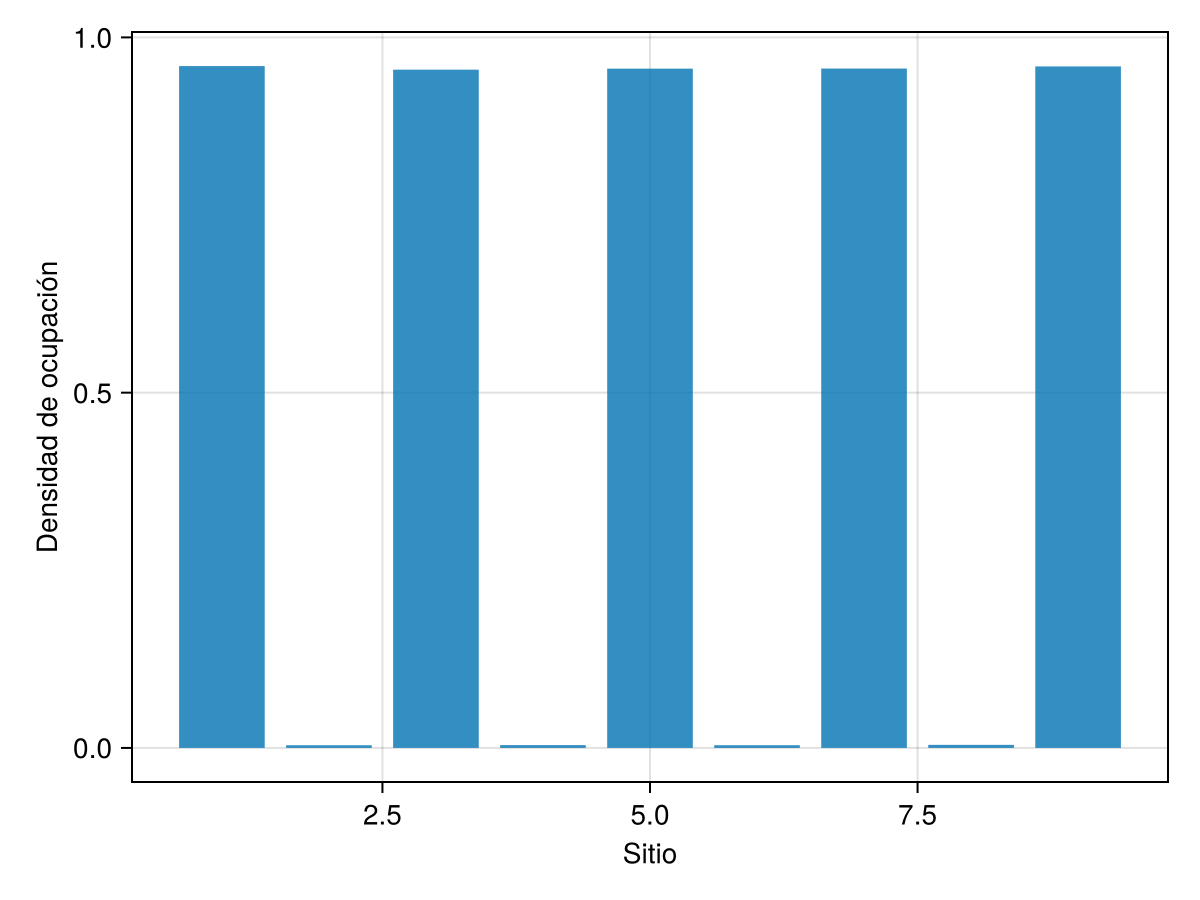

In [11]:
fig = Figure()
ax = Axis(fig[1,1]; xlabel="Sitio", ylabel="Densidad de ocupación")
results_plot = barplot!(ax, densidades_QMC)
results_plot
fig

Como cabe esperar, observamos un patrón $\mathbb{Z}_2$, tal y como se obtuvo por ED. Vamos a intentar un ejemplo que vaya más allá de ED.

Corremos el mismo código que antes, pero sustituyendo la cadena por una red cuadricular de 100 átomos.

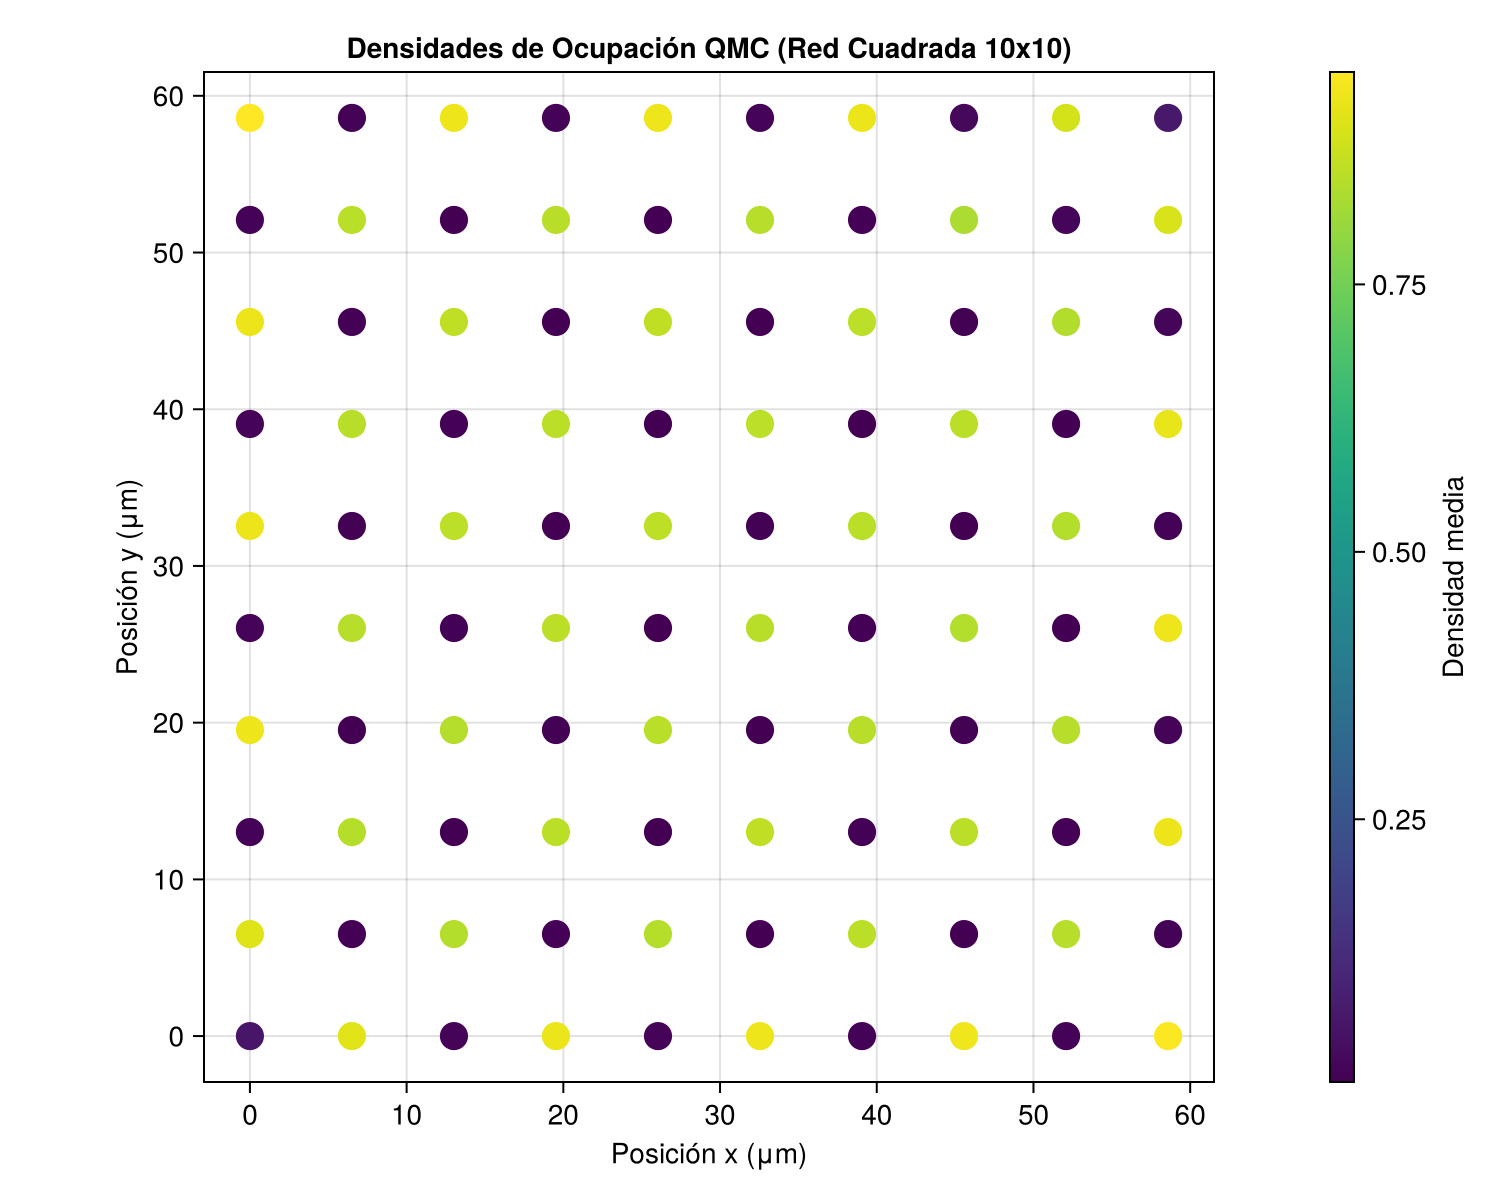

In [16]:
nx = ny = 10
n_sites = nx*ny
atoms = generate_sites(SquareLattice(), nx, ny, scale=6.51);
h = rydberg_h(atoms; Δ, Ω) #Construye el Hamiltoniano de Rydberg 
h_qmc = rydberg_qmc(h);
M = 50;
ts = BinaryThermalState(h_qmc, M);   
d = Diagnostics();

[mc_step_beta!(rng, ts, h_qmc, β, d, eq = true) for i in 1:EQ_MCS] #Fase de equilibración

densidades_QMC = zeros(n_sites);
occs = zeros(MCS, n_sites);

for i in 1:MCS # Monte Carlo steps
    mc_step_beta!(rng, ts, h_qmc, β, d, eq = false) do lsize, ts, h_qmc
        SSE_slice = sample(h_qmc, ts, 1)
        occs[i, :] = ifelse.(SSE_slice .== true, 1.0, 0.0)
    end
end

for jj in 1:n_sites
    densidades_QMC[jj] = mean(occs[:,jj])
end

# 1. Corregido: Iterar directamente sobre 'atoms' para obtener las coordenadas
x_coords = [pos[1] for pos in atoms]
y_coords = [pos[2] for pos in atoms]

# 2. Configurar la figura y el eje
fig = Figure(size = (750, 600))
ax = Axis(fig[1, 1];
    xlabel = "Posición x (μm)",
    ylabel = "Posición y (μm)",
    title = "Densidades de Ocupación QMC (Red Cuadrada 10x10)",
    aspect = DataAspect()) # Mantiene la proporción física de la red cuadrada

# 3. Graficar los datos usando el vector de densidades calculado
plt = scatter!(ax, x_coords, y_coords;
    color = densidades_QMC, 
    markersize = 20, 
    colormap = :viridis)

# 4. Añadir la barra de color
Colorbar(fig[1, 2], plt; label = "Densidad media")

fig

## Cálculo de observables mediante BloqadeQMC

La última pregunta que abarcaremos en este tutorial es cómo calcular observables mediante BloqadeQMC. Estudiaremos la energía durante un barrido del detuning Δ. Además, nos limitaremos a un tamaño abarcable por ED para poder comparar ambos métodos.

Comenzamos volviendo a la configuración de cadena y definiendo los parámetros del Hamiltoniano. Mantendremos la frecuencia de Rabi anterior, es decir, $\Omega = 2\pi \times 4$ MHz. Para el detuning, optamos por la siguiente definición.

In [9]:
n_sites = 9
M= 50
atoms = generate_sites(ChainLattice(), n_sites, scale = 5.72);
Ω = 2π * 4
Δ_step = 15;
Δ = LinRange(-2π * 9, 2π * 9, Δ_step);

Ahora solo necesitamos hacer dos pequeños cambios con respecto al anterior cálculo de Monte Carlo. Primero, para cada valor de Δ especificado en el barrido, corremos una simulación QMC que dará un valor en el plot final de la energía. Segundo, tenemos que guardar el número de operadores contenidos en cada muestra. Aquí es donde entra la imagen que introducimos anteriormente. Este número variará entre muestras a medidas que construimos la cadena de Markov. Viene dada directamente por la función `mc_step_beta!`.

Podemos usar el número de operadores para calcular la energía dada la siguiente observación. Primero, de física estadística sabemos que:
$$ \langle E \rangle = -\frac{\partial ln Z}{\partial \beta} $$
Aunque en el formalismo SSE podemos encontrar otra expresión para $\langle E \rangle$. Volvamos y consideremos el valor esperado de la longitud del operador secuencia:
$$
\begin{aligned}
\langle n \rangle &= \frac{1}{Z} Tr(\sum_{n=0}^\infty n \frac{(-\beta \hat{H})^n}{n!}) \\
                  &= \frac{1}{Z} Tr(\sum_{n=1}^\infty n \frac{(-\beta \hat{H})^n}{n!}) \\
                  &= \frac{1}{Z} Tr(\sum_{n=1}^\infty \frac{(-\beta \hat{H})^n}{(n-1)!}) \\
                  &= \frac{1}{Z} Tr(\sum_{n=0}^\infty (-\beta \hat{H}) * \frac{(-\beta \hat{H})^n}{n!})
\end{aligned}
$$
Donde, en la segunda línea, dejamos el término  $n=0$ y en la cuarta cambiamos el sumatorio sobre $n$ por 1, obteniendo el factor extra $-\beta  \hat{H}$. De aquí, podemos leer directamente la fórmula para el valor medio de la energía para SSE:
$$ \langle E \rangle = -\frac{\langle n \rangle}{\beta} $$

In [13]:
using BinningAnalysis

energia_QMC = [] #Aquí guardaremos las energías.

for ii in 1:Δ_step #Para cada valor de Δ en el sweep.
    #Definimos el hamiltoniano y las variables para MC.
    h_ii = rydberg_h(atoms; Δ = Δ[ii], Ω) 
    h_ii_qmc = rydberg_qmc(h_ii)
    ts_ii = BinaryThermalState(h_ii_qmc, M)
    d_ii = Diagnostics()

    [mc_step_beta!(rng, ts_ii, h_ii_qmc, β, d_ii, eq = true) for i in 1:EQ_MCS] #Fase de equilibrado.

    ns = zeros(MCS)

    for i in 1:MCS #Pasos MC.
        ns[i] = mc_step_beta!(rng, ts_ii, h_ii_qmc, β, d_ii, eq = false)
    end

    energia(x) = -x / β + h_ii_qmc.energy_shift #El shift de energía asegura que todos los elementos de matriz son no negativos.
    BE = LogBinner(energia.(ns)) # Binning analysis
    τ_energia = tau(BE)
    ratio = 2 * τ_energia + 1
    energia_binned = measurement(mean(BE), std_error(BE)*sqrt(ratio))
    append!(energia_QMC, energia_binned)
end

Hay un último punto que vale la pena mencionar al calcular valores esperados utilizando el método MCMC. Como se ha mencionado antes, las muestras no son estadísticamente independientes, sino que están correlacionadas por la propiedad de la cadena de Markov. Este punto es crucial. Depués de todo, Monte Carlo es exacto solo en un sentido estadístico. Debemos construir barras de error alrededor de los valores medios calculados con nuestra simulación. La correlación de las muestras tiene el efecto de reducir la varianza efectiva, otorgando así una precisión que realmente no podemos justificar.

Un método para tratar este problema el el analisis por agrupamiento. La idea es juntar secuencias pequeñas de muestras y promediarlas. Esto da lugar a un tamaño efectivo reducido dado por :
$$ N_{eff} = \frac{N_{orig}}{2\tau + 1}$$
Donde $\tau$ es el tiempo de autocorrelación.

Usamo este tamaño muestral efectivo para reescalar el error estándar en $\sqrt{2\tau +1}$. Para mayor detalle, visitar la documentación del paquete [BinningAnalysis](https://github.com/carstenbauer/BinningAnalysis.jl). Si las barras de error obtenidas así son todavía demasiado grandes, aumentar el número de muestras tomadas (el número de pasos MC) puede ayudar a aliviar el problema.

Finalmente, podemos llevar a cabo el cálculo ED para dibujar ambos métodos juntos.

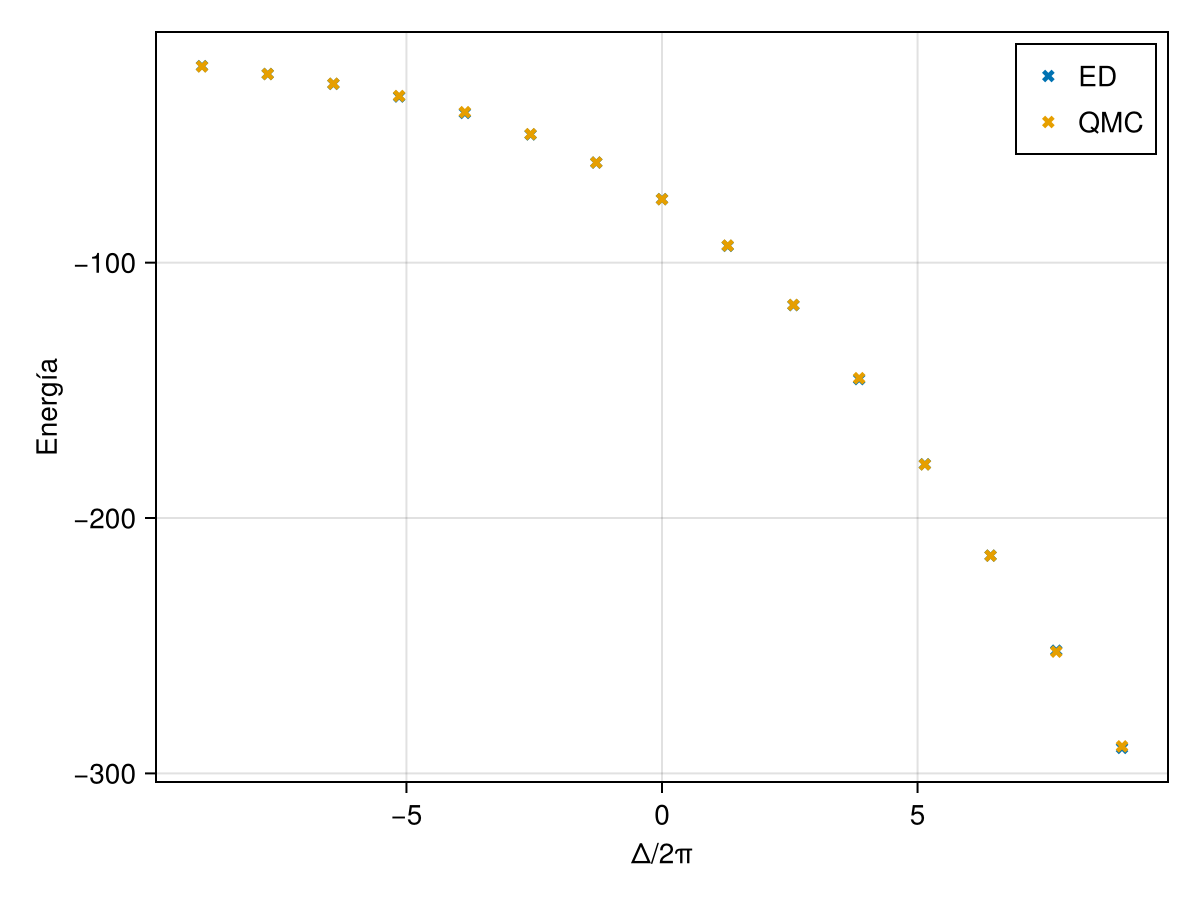

In [15]:
energia_ED = zeros(Δ_step)

for ii in 1:Δ_step
    h_ii = rydberg_h(atoms; Δ = Δ[ii], Ω)
    h_m = Matrix(mat(h_ii))
    energias, vecs = LinearAlgebra.eigen(h_m)

    w = exp.(-β .* (energias .- energias[1]))
    energia_ED[ii] = sum(w .* energias) / sum(w)
end

fig = Figure()
ax = Axis(fig[1,1]; xlabel= "Δ/2π", ylabel="Energía")
scatter!(ax, Δ/2π, energia_ED, label="ED", marker=:x);
errorbars!(ax, Δ/2π, value.(energia_QMC), uncertainty.(energia_QMC))
scatter!(ax, Δ/2π, value.(energia_QMC); label="QMC", marker=:x)
axislegend(ax, position=:rt)
fig

Podemos observar que utilizar QMC otorga los mismos resultados que ED con gran precisión.

Como nota final, también es posible calcular observables en el formalismo SSE si son productos de operadores del hamiltoniano. Por ejemplo, para calcular $\rangle X \langle$, uno contaría el número de veces que aparece el operador no diagonal $\sigma_x$ en cada muestra y tomaría su promedio. Para más ejemplos y demostraciones, consultar [A. Sandvik (10.1088/0305-4470/25/13/017)](https://iopscience.iop.org/article/10.1088/0305-4470/25/13/017/pdf)

Para terminar este tutorial, un plot final de la magnetización que actúa como parámetro de orden para observar la transición del desorden a la fase $\mathbb{Z}_2$ obtenida anteriormente:

In [17]:
densities_QMC = []
order_param_QMC = []

for ii in 1:Δ_step
    h_ii = rydberg_h(atoms; Δ = Δ[ii], Ω)
    h_ii_qmc = rydberg_qmc(h_ii)
    ts_ii = BinaryThermalState(h_ii_qmc,M)
    d_ii = Diagnostics()

    [mc_step_beta!(rng, ts_ii, h_ii_qmc, β, d_ii, eq=true) for i in 1:EQ_MCS] #equilibration phase
    
    order_param = zeros(MCS)

    for i in 1:MCS # Monte Carlo Steps
        mc_step_beta!(rng, ts_ii, h_ii_qmc, β, d_ii, eq=false) do lsize, ts_ii, h_ii_qmc
            SSE_slice = sample(h_ii_qmc, ts_ii, 1) # occ = 0,1
            spin = 2 .* SSE_slice .- 1 # spin = -1, 1
            order_param[i] = abs(sum(spin[1:2:end]) - sum(spin[2:2:end]))/length(spin)
        end
    end

    BD = LogBinner(order_param)
    τ_energy = tau(BD)
    ratio = 2 * τ_energy + 1
    energy_binned = measurement(mean(BD), std_error(BD)*sqrt(ratio)) 
    append!(order_param_QMC, measurement(mean(BD), std_error(BD)*sqrt(ratio)) )
end

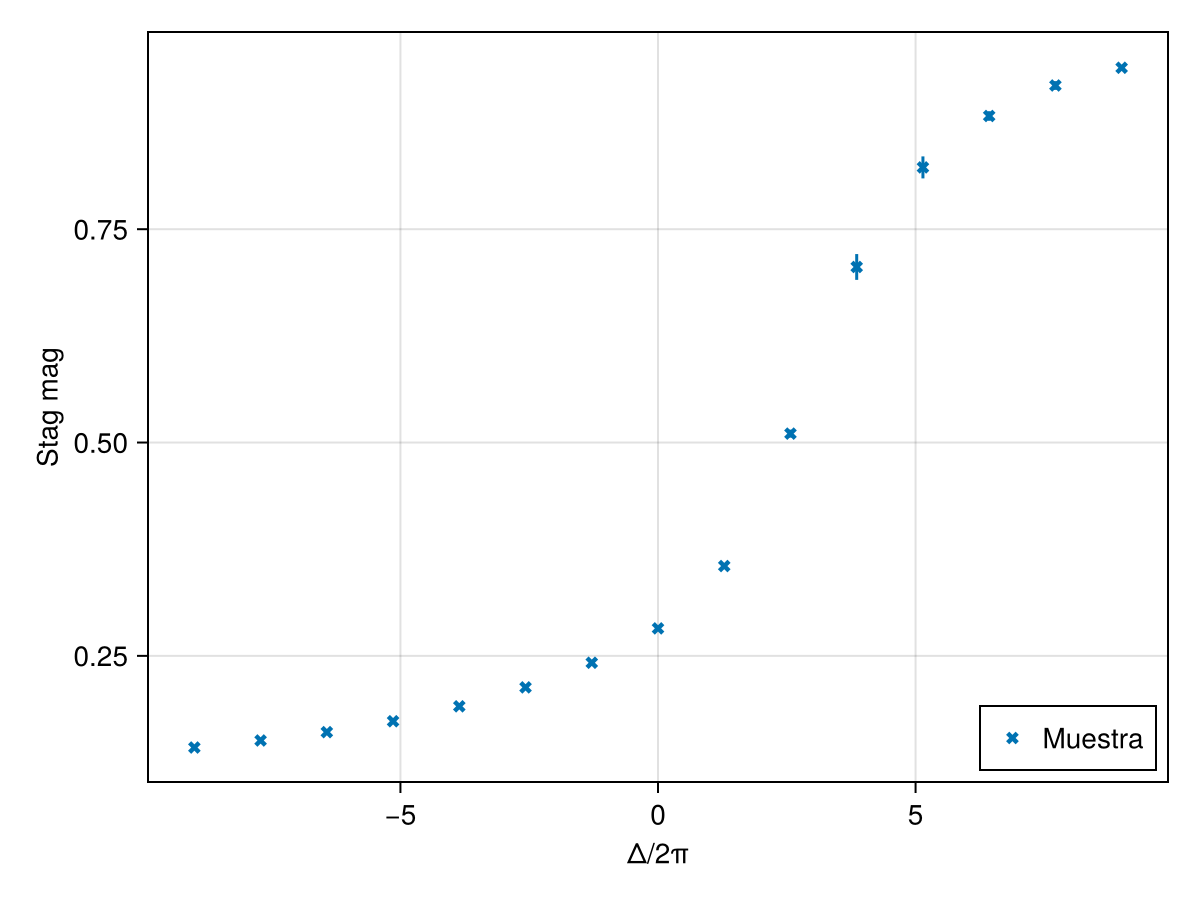

In [18]:
fig = Figure()
ax = Axis(fig[1, 1]; xlabel="Δ/2π", ylabel="Stag mag")
errorbars!(ax, Δ/2π, value.(order_param_QMC), uncertainty.(order_param_QMC))
fig_order = scatter!(ax, Δ/2π, value.(order_param_QMC); label="Muestra", marker=:x)
axislegend(ax, position=:rb)
fig